<a href="https://colab.research.google.com/github/nicolasDavalos/sis420_IA_Davalos_Alvarez_Nicolas_Darko/blob/main/sis420_lab02_mul_pol_nor_davalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importacion de librerias

division de la columna moisture_regime para trabajar con binarios

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/gdrive/MyDrive/IA/lab02_mul_pol_norm/agro_environmental_dataset.csv", low_memory=False)

print(df.shape)

(543210, 25)


In [ ]:
print(df.columns)

Index(['location_id', 'soil_type', 'bulk_density', 'organic_matter_pct',
       'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity',
       'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet',
       'moisture_regime', 'soil_temp_c', 'air_temp_c', 'thermal_regime',
       'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm',
       'phosphorus_ppm', 'potassium_ppm', 'nutrient_balance', 'plant_category',
       'suitability_score', 'stress_level', 'failure_flag'],
      dtype='object')


veremos los valores de la columna (se recomienda no ejecutar una ves mas porque cuando ya esta dividida este codigo manda error en los valores porque ya no existe esta columna sino sus divisiones)

In [ ]:
print(df["moisture_regime"].unique())

['dry' 'optimal' 'waterlogged']


aqui se divide la columna asi que mejor no volver a ejecutar

In [ ]:
df = pd.get_dummies(df, columns=["moisture_regime"])

In [ ]:
print(df.shape)

(543210, 27)


In [ ]:
print(df.columns)

Index(['location_id', 'soil_type', 'bulk_density', 'organic_matter_pct',
       'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity',
       'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet',
       'soil_temp_c', 'air_temp_c', 'thermal_regime', 'light_intensity_par',
       'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm',
       'potassium_ppm', 'nutrient_balance', 'plant_category',
       'suitability_score', 'stress_level', 'failure_flag',
       'moisture_regime_dry', 'moisture_regime_optimal',
       'moisture_regime_waterlogged'],
      dtype='object')


ahora guardaremos el cambio de la division de esta columna (no ejecutar de nuevo porque sino alterara el numero de ejemplo)

In [ ]:
df.to_csv("/content/gdrive/MyDrive/IA/lab02_mul_pol_norm/agro_environmental_dataset.csv", index=False)

importacion de librerias

In [ ]:
  # utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

cargaremos el dataset, definiremos las variables independientes y la dependiente, tambien separaremos las columnas que no usaremos debido a que son letras

In [ ]:
# Librería para manejo de datos
import pandas as pd
import numpy as np

# Cargar dataset
data = pd.read_csv('/content/gdrive/MyDrive/IA/lab02_mul_pol_norm/agro_environmental_dataset.csv')

# -----------------------------------------
# ELIMINAR COLUMNAS CON TEXTO
# -----------------------------------------

data = data.drop(columns=[
    'location_id',
    'soil_type',
    'thermal_regime',
    'nutrient_balance',
    'plant_category'
])

# -----------------------------------------
# VARIABLE DEPENDIENTE
# -----------------------------------------
# Lo que queremos predecir

y = data['potassium_ppm'].values

# -----------------------------------------
# VARIABLES INDEPENDIENTES
# -----------------------------------------

X = data.drop(columns=['potassium_ppm']).values

# Convertir todo a float
X = X.astype(float)
y = y.astype(float)

# -----------------------------------------
# NÚMERO DE EJEMPLOS
# -----------------------------------------

m = y.size

print("Número de ejemplos:", m)

# -----------------------------------------
# DIMENSIONES
# -----------------------------------------

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print("\nPrimeros 10 ejemplos del dataset:\n")

# mostrar primeras filas
print(data.head(10))

Número de ejemplos: 543210
Dimensión de X: (543210, 21)
Dimensión de y: (543210,)

Primeros 10 ejemplos del dataset:

   bulk_density  organic_matter_pct  cation_exchange_capacity  salinity_ec  \
0           1.1                 4.0                        30          0.5   
1           1.3                 3.8                        20          0.4   
2           1.5                 2.0                         8          0.3   
3           1.4                 3.0                        18          0.4   
4           1.3                 3.5                        15          0.3   
5           1.3                 3.5                        15          0.3   
6           1.6                 1.2                         5          0.4   
7           1.6                 1.8                         6          0.6   
8           0.7                18.0                        40          0.2   
9           1.5                 2.0                         8          0.3   

   buffering_capacity  

normalizacion de las variables y la copia del dataset para poder ser manipulado

In [ ]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

llamar a la funcion para ver que todo esta bien

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X[:5])
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm[:5])

[[1.100e+00 4.000e+00 3.000e+01 5.000e-01 9.000e-01 5.170e+00 2.500e+01
  5.200e+01 2.110e+01 2.560e+01 1.027e+03 6.480e+00 0.000e+00 1.001e+02
  5.080e+01 6.770e-01 1.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [1.300e+00 3.800e+00 2.000e+01 4.000e-01 7.000e-01 2.628e+01 1.600e+01
  4.500e+01 3.070e+01 3.030e+01 5.630e+02 6.430e+00 0.000e+00 1.338e+02
  5.490e+01 8.710e-01 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00]
 [1.500e+00 2.000e+00 8.000e+00 3.000e-01 4.000e-01 4.490e+01 1.200e+01
  3.500e+01 3.030e+01 3.410e+01 4.080e+02 5.010e+00 1.000e+00 8.450e+01
  8.360e+01 0.000e+00 2.000e+00 1.000e+00 0.000e+00 0.000e+00 1.000e+00]
 [1.400e+00 3.000e+00 1.800e+01 4.000e-01 6.000e-01 2.705e+01 1.800e+01
  4.200e+01 2.680e+01 3.020e+01 7.290e+02 5.410e+00 1.000e+00 1.682e+02
  3.050e+01 5.100e-01 1.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00]
 [1.300e+00 3.500e+00 1.500e+01 3.000e-01 7.000e-01 3.656e+01 1.500e+01
  4.000e+01 2.260e+01 2.590e+01 3.390e+02 6.730e+00 0.000e+0

agregaremos la columna de 1 al dataser

In [ ]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

verificamos que se haya agregado

In [ ]:
print(X[:5])

[[ 1.00000000e+00 -9.02474574e-01 -7.07865000e-05  1.23345264e+00
  -1.76310763e-01  1.45906367e+00 -2.49896308e+00  1.21752530e+00
   9.74360934e-01 -7.82129740e-01 -4.47494677e-01  1.13280958e+00
  -2.14681355e-02 -5.10008123e-01 -6.89389653e-03  8.66666754e-03
   2.58470948e-01  1.14737824e-01 -4.39917179e-01  3.05359433e+00
  -1.19341232e+00 -6.79137594e-01]
 [ 1.00000000e+00 -7.96671085e-02 -4.68208591e-02  2.68894837e-01
  -2.77728211e-01  4.51908199e-01 -7.29154320e-01 -1.42972968e-01
   2.51363021e-01  1.14130685e+00  4.26267463e-01 -4.73042473e-01
  -7.75017020e-02 -5.10008123e-01  8.54143026e-01  1.80736129e-01
   1.04618279e+00 -1.23033703e+00 -4.39917179e-01 -3.27482924e-01
   8.37933366e-01 -6.79137594e-01]
 [ 1.00000000e+00  7.43140357e-01 -4.67571512e-01 -8.88574530e-01
  -3.79145658e-01 -1.05882501e+00  8.31899171e-01 -7.47638864e-01
  -7.81491139e-01  1.06116366e+00  1.13271345e+00 -1.00948012e+00
  -1.66885499e+00  1.96075308e+00 -4.05474786e-01  1.38522236e+00
  -2.4

definiremos la funcion de costo

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

implementacion del descenso por gradiente

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

graficacion y ejemplo de entrenamiento

mmmmmm al ejecutar vemos que el ejemplo de prediccion fue irrealista pero la thetas estan bien asi que el problema fue los datos introducidos para este ejemplo que no son reales

Theta calculado por el descenso por el gradiente:
[ 1.08310476e+02 -1.54728958e-01  1.24958784e-01  6.61516421e-02
  5.03555408e-01 -1.32690959e-01  1.66959234e-02 -6.90616739e-02
 -1.92015153e-02  1.05717482e-01  1.34701261e-01  1.53099863e-02
 -4.78351743e-03  1.05312736e+00  1.58427280e-02 -3.33541762e-01
  1.83754833e+00 -1.71908761e+00  1.00904967e+00  3.54081803e-01
 -8.69864532e-01  6.96032409e-01]
Predicción de potassium_ppm:
623.1181633250708


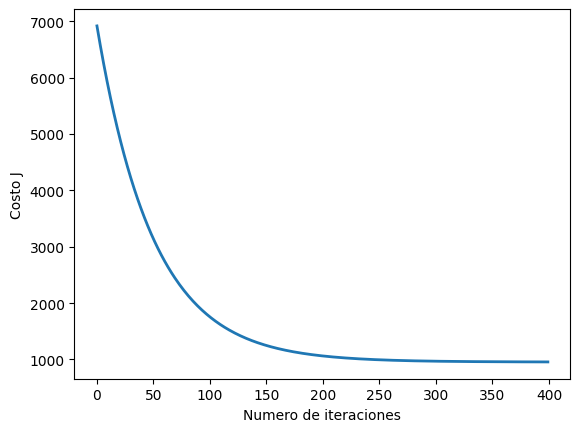

In [ ]:
# Elegir algun valor para alpha
alpha = 0.01
num_iters = 400

# inicializa theta
theta = np.zeros(X.shape[1])

# ejecutar descenso por gradiente
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Mostrar parámetros
print('Theta calculado por el descenso por el gradiente:')
print(theta)

# -------------------------------
# EJEMPLO DE PREDICCIÓN
# -------------------------------

# valores ejemplo (según columnas del dataset agroambiental)
X_example = np.array([
1.3,    # bulk_density
4.5,    # organic_matter_pct
18,     # cation_exchange_capacity
1.2,    # salinity_ec
2.1,    # buffering_capacity
35,     # soil_moisture_pct
15,     # moisture_limit_dry
40,     # moisture_limit_wet
22,     # soil_temp_c
25,     # air_temp_c
800,    # light_intensity_par
6.5,    # soil_ph
0,      # ph_stress_flag
40,     # nitrogen_ppm
20,     # phosphorus_ppm
70,     # suitability_score
1,      # stress_level
0,      # failure_flag
0,      # moisture_regime_dry
1,      # moisture_regime_optimal
0       # moisture_regime_waterlogged
])

# normalizar usando mu y sigma calculados antes
X_example_norm = (X_example - mu) / sigma

# añadir termino de intersección
X_example_final = np.concatenate(([1], X_example_norm))

# predicción
pred_potassium = np.dot(X_example_final, theta)

print("Predicción de potassium_ppm:")
print(pred_potassium)

en este codigo vemos un ejemplo real y su prediccion es mas confiable

In [ ]:
# -------------------------------
# EJEMPLO DE PREDICCIÓN REAL
# -------------------------------

# tomar un ejemplo real del dataset
X_example = X_norm[0]

# añadir termino de intersección
X_example_final = np.concatenate(([1], X_example))

# predicción
pred_potassium = np.dot(X_example_final, theta)

print("Predicción de potassium_ppm:")
print(pred_potassium)

print("Valor real del dataset:")
print(y[0])

Predicción de potassium_ppm:
108.91961545070589
Valor real del dataset:
121.3


realizaremos las 100 predicciones tmando valores randoom que formaran 100 filas usando un promedio del dataset, luego se normaliza y de calcula la prediccion

In [ ]:
# -------------------------------------
# 100 PREDICCIONES CON VALORES RANDOM
# -------------------------------------

# generar valores random usando SOLO las variables reales
X_random = np.random.uniform(
    low=X[:,1:].min(axis=0),
    high=X[:,1:].max(axis=0),
    size=(100, X.shape[1]-1)
)

# normalizar
X_random_norm = (X_random - mu) / sigma

# agregar columna de intersección
X_random_final = np.concatenate([np.ones((100,1)), X_random_norm], axis=1)

# predicciones
predicciones = np.dot(X_random_final, theta)

# mostrar resultados
for i in range(100):
    print(f"Predicción {i+1}: {predicciones[i]:.2f} ppm")

Predicción 1: 98.16 ppm
Predicción 2: 94.26 ppm
Predicción 3: 94.30 ppm
Predicción 4: 112.41 ppm
Predicción 5: 102.64 ppm
Predicción 6: 111.14 ppm
Predicción 7: 107.69 ppm
Predicción 8: 120.40 ppm
Predicción 9: 112.11 ppm
Predicción 10: 96.18 ppm
Predicción 11: 107.24 ppm
Predicción 12: 96.13 ppm
Predicción 13: 107.33 ppm
Predicción 14: 116.02 ppm
Predicción 15: 119.18 ppm
Predicción 16: 111.87 ppm
Predicción 17: 112.02 ppm
Predicción 18: 90.36 ppm
Predicción 19: 131.92 ppm
Predicción 20: 102.28 ppm
Predicción 21: 102.93 ppm
Predicción 22: 113.84 ppm
Predicción 23: 103.13 ppm
Predicción 24: 117.51 ppm
Predicción 25: 117.13 ppm
Predicción 26: 120.71 ppm
Predicción 27: 117.79 ppm
Predicción 28: 107.99 ppm
Predicción 29: 116.74 ppm
Predicción 30: 115.43 ppm
Predicción 31: 115.55 ppm
Predicción 32: 97.27 ppm
Predicción 33: 103.13 ppm
Predicción 34: 111.28 ppm
Predicción 35: 115.88 ppm
Predicción 36: 100.62 ppm
Predicción 37: 110.44 ppm
Predicción 38: 124.18 ppm
Predicción 39: 101.56 ppm
Pr

ECUACION DE LA NORMAL

volvemos a cargar el dataset modificado y a hacer la separacion de variables

In [ ]:
# Volver a cargar el dataset procesado
data = pd.read_csv('/content/gdrive/MyDrive/IA/lab02_mul_pol_norm/agro_environmental_dataset.csv')

# eliminar columnas de texto
data = data.drop(columns=[
    'location_id',
    'soil_type',
    'thermal_regime',
    'nutrient_balance',
    'plant_category'
])

# variable dependiente
y = data['potassium_ppm'].values.astype(float)

# variables independientes
X_df = data.drop(columns=['potassium_ppm'])

# convertir TODO a numérico
X_df = X_df.apply(pd.to_numeric, errors='coerce')

# convertir a numpy
X = X_df.values.astype(float)

# número de ejemplos
m = y.size
print("Número de ejemplos:", m)

# agregar columna de intersección
X = np.concatenate([np.ones((m, 1)), X], axis=1)

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Número de ejemplos: 543210
Dimensión de X: (543210, 22)
Dimensión de y: (543210,)


In [ ]:
print(feature_names)

Index(['bulk_density', 'organic_matter_pct', 'cation_exchange_capacity',
       'salinity_ec', 'buffering_capacity', 'soil_moisture_pct',
       'moisture_limit_dry', 'moisture_limit_wet', 'soil_temp_c', 'air_temp_c',
       'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm',
       'phosphorus_ppm', 'suitability_score', 'stress_level', 'failure_flag',
       'moisture_regime_dry', 'moisture_regime_optimal',
       'moisture_regime_waterlogged'],
      dtype='object')


In [ ]:
print(X.dtype)

float64


definimos la ecuacion de la normal

In [ ]:
def normalEqn(X, y):

    theta = np.dot(np.linalg.pinv(X), y)

    return theta

ejemplo

In [ ]:
# Calcula los parámetros con ecuación normal
theta = normalEqn(X, y)

# Mostrar parámetros
print('Theta calculado a partir de la ecuación de la normal:')
print(theta)
print("Cantidad de parámetros en theta:", len(theta))


# -----------------------------
# EJEMPLO DE PREDICCIÓN
# -----------------------------
# valores de ejemplo del dataset agroambiental

X_array = np.array([
1,      # término de intersección
1.3,    # bulk_density
3.5,    # organic_matter_pct
15,     # cation_exchange_capacity
2.1,    # salinity_ec
8.0,    # buffering_capacity
25,     # soil_moisture_pct
10,     # moisture_limit_dry
40,     # moisture_limit_wet
22,     # soil_temp_c
24,     # air_temp_c
500,    # light_intensity_par
6.5,    # soil_ph
0,      # ph_stress_flag
35,     # nitrogen_ppm
20,     # phosphorus_ppm
0.8,    # suitability_score
2,      # stress_level
0,      # failure_flag
0,      # moisture_regime_dry
1,      # moisture_regime_optimal
0       # moisture_regime_waterlogged
])

# predicción
pred = np.dot(X_array, theta)

print("Predicción de potassium_ppm con ecuación normal:")
print(pred)

Theta calculado a partir de la ecuación de la normal:
[ 9.43353792e+01 -1.32382093e+01 -3.79281546e-01 -4.90311691e-02
  5.23216286e-01 -8.36167579e+00 -1.58964891e-02  5.53706530e-02
  1.09880010e-02  3.49457617e-02  2.92795962e-02  4.81669163e-05
  6.26129349e-02  4.17583726e+00  8.06141399e-04 -2.10871070e-02
  1.36119845e+01 -1.86185378e+00  3.55974095e+00  3.23339370e+01
  2.84957583e+01  3.35056839e+01]
Cantidad de parámetros en theta: 22
Predicción de potassium_ppm con ecuación normal:
47.03461217208442


100 predicciones con la ecuacion de la normal

In [ ]:
# -------------------------------------
# 100 PREDICCIONES RANDOM (ECUACIÓN NORMAL)
# -------------------------------------

# generar 100 valores aleatorios dentro del rango real
X_random = np.random.uniform(
    low=X[:,1:].min(axis=0),
    high=X[:,1:].max(axis=0),
    size=(100, X.shape[1]-1)
)

# agregar columna de intersección
X_random_final = np.concatenate([np.ones((100,1)), X_random], axis=1)

# predicciones
predicciones = np.dot(X_random_final, theta)

# mostrar resultados
for i in range(100):
    print(f"Predicción {i+1}: {predicciones[i]:.2f} ppm")

Predicción 1: 134.72 ppm
Predicción 2: 151.35 ppm
Predicción 3: 110.22 ppm
Predicción 4: 149.74 ppm
Predicción 5: 120.30 ppm
Predicción 6: 159.38 ppm
Predicción 7: 109.87 ppm
Predicción 8: 156.54 ppm
Predicción 9: 131.53 ppm
Predicción 10: 121.63 ppm
Predicción 11: 124.17 ppm
Predicción 12: 142.20 ppm
Predicción 13: 139.52 ppm
Predicción 14: 125.60 ppm
Predicción 15: 107.01 ppm
Predicción 16: 125.77 ppm
Predicción 17: 146.04 ppm
Predicción 18: 120.57 ppm
Predicción 19: 142.83 ppm
Predicción 20: 114.32 ppm
Predicción 21: 109.43 ppm
Predicción 22: 133.06 ppm
Predicción 23: 132.34 ppm
Predicción 24: 123.25 ppm
Predicción 25: 105.09 ppm
Predicción 26: 145.86 ppm
Predicción 27: 148.10 ppm
Predicción 28: 141.90 ppm
Predicción 29: 135.13 ppm
Predicción 30: 107.24 ppm
Predicción 31: 126.48 ppm
Predicción 32: 103.62 ppm
Predicción 33: 142.81 ppm
Predicción 34: 125.92 ppm
Predicción 35: 131.67 ppm
Predicción 36: 107.27 ppm
Predicción 37: 100.01 ppm
Predicción 38: 118.02 ppm
Predicción 39: 152.84

POLINOMIAL

cargar los datos

In [ ]:
# Cargar dataset agroambiental
data = pd.read_csv('/content/gdrive/MyDrive/IA/lab02_mul_pol_norm/agro_environmental_dataset.csv')

# eliminar columnas de texto
data = data.drop(columns=[
    'location_id',
    'soil_type',
    'thermal_regime',
    'nutrient_balance',
    'plant_category'
])

# variable dependiente
y = data['potassium_ppm'].values

# variables independientes
X = data.drop(columns=['potassium_ppm']).values

# número de ejemplos
m = y.size

print("Número de ejemplos:", m)
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

# mostrar primeros 10 registros
print("\nPrimeros 10 registros:")
print(data.head(10))

Número de ejemplos: 543210
Dimensión de X: (543210, 21)
Dimensión de y: (543210,)

Primeros 10 registros:
   bulk_density  organic_matter_pct  cation_exchange_capacity  salinity_ec  \
0           1.1                 4.0                        30          0.5   
1           1.3                 3.8                        20          0.4   
2           1.5                 2.0                         8          0.3   
3           1.4                 3.0                        18          0.4   
4           1.3                 3.5                        15          0.3   
5           1.3                 3.5                        15          0.3   
6           1.6                 1.2                         5          0.4   
7           1.6                 1.8                         6          0.6   
8           0.7                18.0                        40          0.2   
9           1.5                 2.0                         8          0.3   

   buffering_capacity  soil_moistur

graficacion

In [ ]:
def plotData(x, y):

    fig = pyplot.figure()

    pyplot.plot(x, y, 'ro', ms=4, mec='k')
    pyplot.ylabel('Potassium (ppm)')
    pyplot.xlabel('Soil Moisture (%)')

ver la grafica

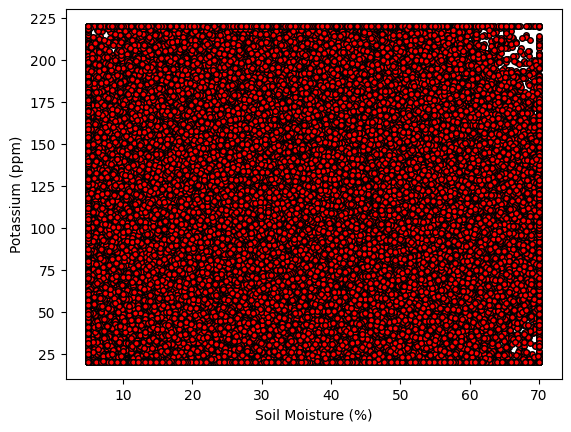

In [ ]:
# graficar soil moisture vs potassium
plotData(X[:,5], y)

crear la regrecion polinomica

In [ ]:
X_poly = np.concatenate([X_norm, X_norm**2], axis=1)

print("Dimensión de X polinómico:", X_poly.shape)

Dimensión de X polinómico: (543210, 42)


In [ ]:
X_poly = np.concatenate([np.ones((m,1)), X_poly], axis=1)

normalizacion

In [ ]:
def featureNormalize(X):

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # evitar división por cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

 la normalizacion y la media calculada

In [ ]:
# normalizar variables polinómicas
X_poly_norm, mu, sigma = featureNormalize(X_poly)

print("Dimensión de X polinómico normalizado:", X_poly_norm.shape)

#print('Media calculada:', mu)
#print('Desviación estandar calculada:', sigma)
#print(X_poly_norm[:5])

Dimensión de X polinómico normalizado: (543210, 43)


In [ ]:
print(X_norm)

[[-9.02474574e-01 -7.07865000e-05  1.23345264e+00 ...  3.05359433e+00
  -1.19341232e+00 -6.79137594e-01]
 [-7.96671085e-02 -4.68208591e-02  2.68894837e-01 ... -3.27482924e-01
   8.37933366e-01 -6.79137594e-01]
 [ 7.43140357e-01 -4.67571512e-01 -8.88574530e-01 ... -3.27482924e-01
  -1.19341232e+00  1.47245567e+00]
 ...
 [-9.02474574e-01 -7.07865000e-05  1.23345264e+00 ... -3.27482924e-01
   8.37933366e-01 -6.79137594e-01]
 [-7.96671085e-02 -4.68208591e-02  2.68894837e-01 ... -3.27482924e-01
   8.37933366e-01 -6.79137594e-01]
 [-7.96671085e-02 -1.16945968e-01 -2.13384066e-01 ... -3.27482924e-01
  -1.19341232e+00  1.47245567e+00]]


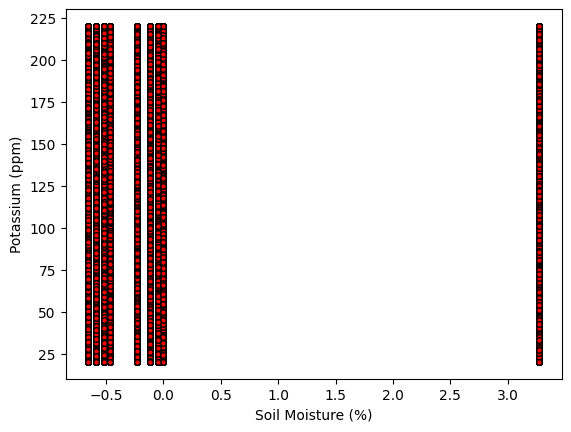

In [ ]:
plotData(X_norm[:,1], y)

añadir el termino de iterseccion

In [ ]:
# Añade el término de intersección a las variables polinómicas
X_poly = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

print("Dimensión final de X polinómico:", X_poly.shape)

Dimensión final de X polinómico: (543210, 44)


DESCENSO POR GRADIENTE

funcion de costo

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

se define la funcion de descenso por grdiente

In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

grafica e impresion de resultados

Theta calculado por descenso por gradiente:
[ 1.08310476e+02  0.00000000e+00 -7.30161200e-02 -1.55148618e-02
  6.05054172e-03  3.24919355e-01  2.48464149e-02 -1.07106202e-02
 -5.77277530e-02 -9.17701143e-03  1.58685470e-01  1.74493099e-01
  1.54598931e-02 -2.90940719e-02  5.75825762e-01  6.31036888e-03
 -4.12748860e-01  2.24747421e+00 -1.92624119e+00  4.05046173e-01
  2.18212786e-01 -5.60139588e-01  4.54435027e-01  1.52090410e-02
  1.67890282e-02  7.24584657e-02  3.36385499e-01  1.19580762e-01
 -1.10730872e-01  1.47265427e-01  3.95383493e-02  5.68314803e-01
  1.83455414e-01  1.05103743e-01  4.33872215e-01  5.75825762e-01
  1.88708340e-01  1.25419867e-01  9.54467532e-02  5.64032600e-02
  4.05046173e-01  2.18212786e-01  5.60139588e-01  4.54435027e-01]
Cantidad de parámetros: 44


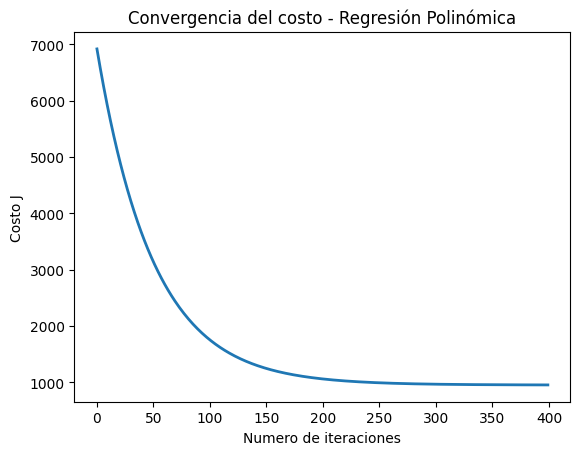

In [ ]:
# Elegir algún valor para alpha
alpha = 0.01
num_iters = 400

# inicializar theta según el número de columnas de X_poly
theta = np.zeros(X_poly.shape[1])

# ejecutar descenso por gradiente
theta, J_history = gradientDescentMulti(X_poly, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo - Regresión Polinómica')

# Mostrar parámetros
print('Theta calculado por descenso por gradiente:')
print(theta)
print("Cantidad de parámetros:", len(theta))

100 predicciones

In [ ]:
# -------------------------------------
# 100 PREDICCIONES POLINÓMICAS
# -------------------------------------

# seleccionar 100 filas aleatorias de los datos normalizados
indices = np.random.choice(X_norm.shape[0], 100, replace=False)

X_test_norm = X_norm[indices]

# crear variables polinómicas
X_test_poly = np.concatenate([X_test_norm, X_test_norm**2], axis=1)

# agregar intersección
X_test_poly = np.concatenate([np.ones((100,1)), X_test_poly], axis=1)

# ajustar columnas automáticamente al tamaño de theta
if X_test_poly.shape[1] < len(theta):
    diff = len(theta) - X_test_poly.shape[1]
    X_test_poly = np.concatenate([X_test_poly, np.zeros((100, diff))], axis=1)

if X_test_poly.shape[1] > len(theta):
    X_test_poly = X_test_poly[:, :len(theta)]

# predicciones
predicciones = np.dot(X_test_poly, theta)

# mostrar resultados
for i in range(100):
    print(f"Predicción {i+1}: {predicciones[i]:.2f} ppm")

Predicción 1: 117.48 ppm
Predicción 2: 111.89 ppm
Predicción 3: 112.19 ppm
Predicción 4: 109.32 ppm
Predicción 5: 114.42 ppm
Predicción 6: 109.45 ppm
Predicción 7: 107.57 ppm
Predicción 8: 109.61 ppm
Predicción 9: 109.92 ppm
Predicción 10: 115.33 ppm
Predicción 11: 110.45 ppm
Predicción 12: 113.19 ppm
Predicción 13: 115.20 ppm
Predicción 14: 111.53 ppm
Predicción 15: 113.19 ppm
Predicción 16: 109.49 ppm
Predicción 17: 112.81 ppm
Predicción 18: 111.67 ppm
Predicción 19: 109.22 ppm
Predicción 20: 108.77 ppm
Predicción 21: 113.19 ppm
Predicción 22: 108.07 ppm
Predicción 23: 115.62 ppm
Predicción 24: 112.10 ppm
Predicción 25: 113.66 ppm
Predicción 26: 112.88 ppm
Predicción 27: 108.28 ppm
Predicción 28: 112.25 ppm
Predicción 29: 110.83 ppm
Predicción 30: 108.79 ppm
Predicción 31: 107.66 ppm
Predicción 32: 118.65 ppm
Predicción 33: 112.00 ppm
Predicción 34: 116.86 ppm
Predicción 35: 107.88 ppm
Predicción 36: 108.04 ppm
Predicción 37: 115.26 ppm
Predicción 38: 118.21 ppm
Predicción 39: 121.26